# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# для 4.4.1
import phik 
import seaborn as sns

In [2]:
pip list

Package                   Version
------------------------- -----------
anyio                     4.13.0
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.7
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.11
ipykernel        

In [3]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [5]:
engine = create_engine(connection_string)

In [6]:
query = '''
SELECT *
FROM afisha.purchases
'''

In [7]:
df_base = pd.read_sql(query, engine)
df_base.head() # проверяем работоспособность подключения

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total
0,1,3ebd0c4b59f6bdd,2024-08-08,2024-08-08 15:01:11,555432,нет,16,rub,mobile,568.43,Облачко,2,5684.33
1,30,1a66f181a803c75,2024-09-05,2024-09-05 19:44:21,149337,нет,16,rub,mobile,575.08,Край билетов,2,6389.80
2,59,1a66f181a803c75,2024-07-25,2024-07-25 10:09:41,269938,нет,12,rub,desktop,402.51,Лови билет!,4,6708.45
3,88,7997823870f2b1b,2024-09-26,2024-09-26 16:03:44,561834,нет,18,rub,mobile,487.94,Мой билет,2,3753.35
4,117,1c5bac640c12e86,2024-09-15,2024-09-15 14:18:07,568660,нет,0,rub,mobile,8.95,Лови билет!,2,447.38


In [8]:
df_base.info() # изучаем информацию о БД

<class 'pandas.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               292034 non-null  int64         
 1   user_id                292034 non-null  str           
 2   created_dt_msk         292034 non-null  datetime64[us]
 3   created_ts_msk         292034 non-null  datetime64[us]
 4   event_id               292034 non-null  int64         
 5   cinema_circuit         292034 non-null  str           
 6   age_limit              292034 non-null  int64         
 7   currency_code          292034 non-null  str           
 8   device_type_canonical  292034 non-null  str           
 9   revenue                292034 non-null  float64       
 10  service_name           292034 non-null  str           
 11  tickets_count          292034 non-null  int64         
 12  total                  292034 non-null  float64       


На данном этапе не хватает некоторых строк. Добавим их через JOIN'ы

In [9]:
query = '''
SELECT
    p.*,
    e.event_type_main,
    c.city_name,
    r.region_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e ON e.event_id = p.event_id
LEFT JOIN afisha.city AS c ON c.city_id = e.city_id
LEFT JOIN afisha.regions AS r ON r.region_id = c.region_id
''' # добавляем три новых столбца из других таблиц

In [10]:
df = pd.read_sql(query, engine)
df = df.rename(columns={
    'created_dt_msk': 'order_dt',
    'created_ts_msk': 'order_ts'
}) # переименовываем два столбца под нужный формат

In [11]:
df = df.sort_values(['user_id', 'order_ts']) # добавляем days_since_prev
df['days_since_prev'] = df.groupby('user_id')['order_ts'].diff().dt.days

In [12]:
df = df.drop(columns=['cinema_circuit', 'age_limit', 'total']) # удаляем лишние столбцы

In [13]:
df.info() # изучаем информацию о БД

<class 'pandas.DataFrame'>
Index: 292034 entries, 147071 to 27456
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               292034 non-null  int64         
 1   user_id                292034 non-null  str           
 2   order_dt               292034 non-null  datetime64[us]
 3   order_ts               292034 non-null  datetime64[us]
 4   event_id               292034 non-null  int64         
 5   currency_code          292034 non-null  str           
 6   device_type_canonical  292034 non-null  str           
 7   revenue                292034 non-null  float64       
 8   service_name           292034 non-null  str           
 9   tickets_count          292034 non-null  int64         
 10  event_type_main        292034 non-null  str           
 11  city_name              292034 non-null  str           
 12  region_name            292034 non-null  str           
 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

**Промежуточный вывод:**

Датасет содержит 292 034 строк, все необходимые признаки присутствуют. Типы данных корректны.

Пропуски есть только в `days_since_prev` для пользователей с одной покупкой.

Лишние столбцы: `cinema_circuit`, `age_limit`, `total` были удалены.


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [14]:
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [15]:
tenge['data'] = pd.to_datetime(tenge['data'])
df = df.merge(tenge, left_on='order_dt', right_on='data', how='left')

In [16]:
df['revenue_rub'] = df['revenue']
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df['revenue'] * df['curs'] / 100
)

In [17]:
df[df['currency_code'] == 'kzt'][['revenue', 'revenue_rub']].head()

,revenue,revenue_rub
73,518.10,98.503762
92,347.18,65.731589
99,328.77,61.148261
289,22021.55,4380.702898
472,3698.83,739.148295


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [18]:
# проверка числовых значений
df[['revenue_rub', 'tickets_count']].describe()

# проверка категорий
df['device_type_canonical'].value_counts()
df['currency_code'].value_counts()

currency_code
rub    286961
kzt      5073
Name: count, dtype: int64

In [19]:
# статистика
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,292034.000000,292034.000000
mean,555.106238,2.754508
std,874.381090,1.170305
min,-90.760000,1.000000
25%,113.480000,2.000000
50%,350.330000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


<Axes: >

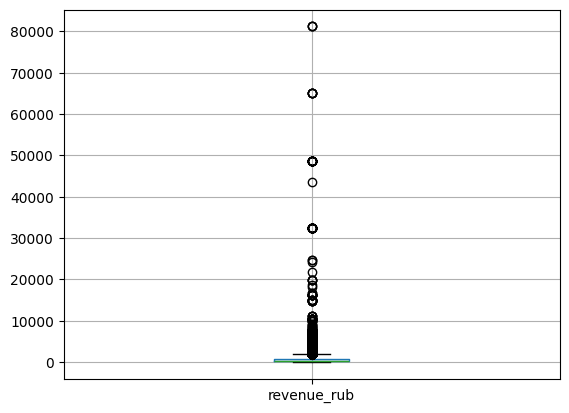

In [20]:
# проверяем выбросы
df.boxplot(column='revenue_rub')

Так как выбросов много - делаем фильтрацию

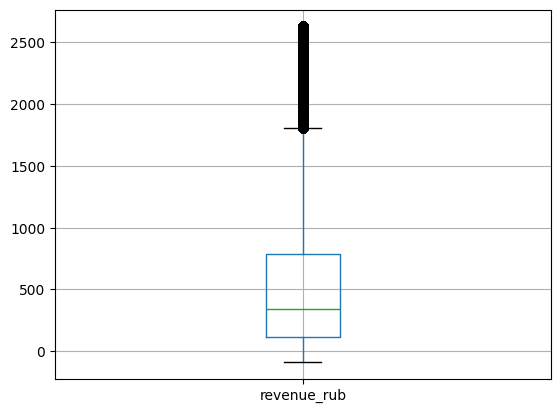

In [21]:
# считаем 99 перцентиль
p99 = df['revenue_rub'].quantile(0.99)

# фильтруем выбросы
df = df[df['revenue_rub'] <= p99]

df.boxplot(column='revenue_rub') # визуализация после удаления выбросов
plt.show()

In [22]:
# проверяем сколько было отфильтровано данных

len_before = 292034 # было
len_after = len(df) # стало

# доля удалённых
removed_share = round(1 - len_after / len_before, 5)
print(f"Изначально было {len_before} данных. После фильтрации их стало {len_after}. Доля удаленных данных - {removed_share}")

Изначально было 292034 данных. После фильтрации их стало 289194. Доля удаленных данных - 0.00972


Данные очищены и подготовлены. Выручка приведена к рублям `revenue_rub`, рассчитан `days_since_prev`. Выбросы удалены по 99 перцентилю, удалена незначительная доля данных (около 2.9%).


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [23]:
# сортировка
df = df.sort_values(['user_id', 'order_ts'])

In [24]:
# строим профиль пользователя, добавляя нужные параметры по заданию.
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_service=('service_name', 'first'),
    orders_count=('order_id', 'nunique'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

In [25]:
# добавляем бинарные признаки
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

In [26]:
# проверяем результаты
user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_service,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Край билетов,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Мой билет,2,774.010000,3.000000,74.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Лови билет!,3,767.213333,2.666667,50.5,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Край билетов,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Лучшие билеты,2,61.310000,1.500000,15.0,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [27]:
print(f"""
    Общее число пользователей: {user_profile['user_id'].nunique()} 
    Средняя выручка с заказа: {float(round(user_profile['avg_revenue_rub'].mean(), 2))}
    Доля пользователя с ≥2 заказами {float(round(user_profile['is_two'].mean(), 3))} 
    Доля пользователя с ≥2 заказами {float(round(user_profile['is_five'].mean(), 3))}
""")


    Общее число пользователей: 21920 
    Средняя выручка с заказа: 543.46
    Доля пользователя с ≥2 заказами 0.618 
    Доля пользователя с ≥2 заказами 0.29



In [28]:
user_profile[['orders_count', 'avg_tickets', 'avg_days_between']].describe() # описательная статистика

,orders_count,avg_tickets,avg_days_between
count,21920.000000,21920.000000,13568.000000
mean,13.193157,2.742845,15.574932
std,122.132781,0.912611,22.223298
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.800000
50%,2.000000,2.750000,7.800000
75%,5.000000,3.072321,20.000000
max,10243.000000,11.000000,148.000000


In [29]:
# проверка аномалий по топу по заказам
user_profile.sort_values('orders_count', ascending=False).head()

,user_id,first_order_dt,last_order_dt,first_device,first_service,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
984,0beb8fc0c0a9ce1,2024-06-01,2024-10-31,mobile,Билеты в руки,10243,504.241087,2.863028,0.0,1,1
2060,18e9aead0a393e7,2024-06-01,2024-10-31,mobile,Облачко,4361,495.312263,2.789269,0.0,1,1
11104,8187dac4be757a0,2024-06-01,2024-10-31,mobile,Билеты в руки,4067,534.250472,2.743300,0.0,1,1
5425,3ee7dc2e115847f,2024-06-01,2024-10-31,mobile,Мой билет,3804,536.567350,2.764984,0.0,1,1
10841,7eb4fc207ecc10f,2024-06-01,2024-10-31,mobile,Билеты без проблем,3725,542.256175,2.955705,0.0,1,1


In [30]:
# проверка аномалий по топу по билетам
user_profile.sort_values('avg_tickets', ascending=False).head()

,user_id,first_order_dt,last_order_dt,first_device,first_service,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
8863,6713518780e7e81,2024-08-30,2024-08-30,desktop,Билеты без проблем,1,116.24,11.000000,NaN,0,0
2366,1c8a65abba03a4c,2024-09-21,2024-09-21,desktop,Билеты без проблем,1,1253.86,10.000000,NaN,0,0
6424,4a815181dcec5f0,2024-09-29,2024-09-29,mobile,Билеты без проблем,1,878.51,10.000000,NaN,0,0
1404,1118cc4889189db,2024-10-23,2024-10-23,mobile,Мой билет,2,677.10,9.000000,0.0,1,0
10140,76694a971889caa,2024-10-04,2024-10-18,desktop,Весь в билетах,3,647.14,8.666667,6.0,1,0


In [31]:
# фильтруем выбросы

p99_orders = user_profile['orders_count'].quantile(0.99)
p99_tickets = user_profile['avg_tickets'].quantile(0.99)

user_profile_filtered = user_profile[
    (user_profile['orders_count'] <= p99_orders) &
    (user_profile['avg_tickets'] <= p99_tickets)
]

In [32]:
# обновленная статистика
user_profile_filtered[['orders_count', 'avg_tickets', 'avg_days_between']].describe()

,orders_count,avg_tickets,avg_days_between
count,21507.000000,21507.000000,13284.000000
mean,6.535640,2.713651,15.872067
std,14.328257,0.864603,22.330079
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.057158
50%,2.000000,2.750000,8.000000
75%,5.000000,3.000000,20.400000
max,152.000000,5.000000,148.000000


In [33]:
# объём данных до и после фильтрации
len_before = len(user_profile)
len_after = len(user_profile_filtered)

removed = len_before - len_after
share = removed / len_before

print(f"Было удалено {removed} пользователей. Что составило примерно {share:.2%} от изначального числа")

Было удалено 413 пользователей. Что составило примерно 1.88% от изначального числа


## Вывод
После фильтрации по 99 перцентилю была удалена небольшая доля пользователей (не более 2%). Обновлённые статистические показатели отражают поведение основной части пользователей и не содержат аномальных значений.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [34]:
# сортируем по времени заказа
df = df.sort_values(['user_id', 'order_ts'])

# считаем дни с предыдущего заказа пользователя
df['days_since_prev'] = (
    df.groupby('user_id')['order_ts'].diff().dt.days
)

In [35]:
df.columns

Index(['order_id', 'user_id', 'order_dt', 'order_ts', 'event_id',
       'currency_code', 'device_type_canonical', 'revenue', 'service_name',
       'tickets_count', 'event_type_main', 'city_name', 'region_name',
       'days_since_prev', 'data', 'nominal', 'curs', 'cdx', 'revenue_rub'],
      dtype='str')

In [36]:
# обновляем профиль пользователя
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_service=('service_name', 'first'),
    first_region=('region_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    orders_count=('order_id', 'nunique'),
    avg_revenue_rub=('revenue', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

In [37]:
# группируем пользователей по типу первого мероприятия
event_segments = user_profile.groupby('first_event_type').agg(
    users=('user_id', 'count')
).reset_index()

# считаем долю пользователей
event_segments['share'] = event_segments['users'] / event_segments['users'].sum()

# сортируем
event_segments = event_segments.sort_values('users', ascending=False)

event_segments

,first_event_type,users,share
2,концерты,9656,0.440511
1,другое,5496,0.250730
5,театр,4310,0.196624
4,стендап,1116,0.050912
3,спорт,804,0.036679
0,выставки,418,0.019069
7,ёлки,93,0.004243
6,фильм,27,0.001232


In [38]:
# группируем пользователей по устройству первой покупки
device_segments = user_profile.groupby('first_device').agg(
    users=('user_id', 'count')
).reset_index()

# считаем долю пользователей
device_segments['share'] = device_segments['users'] / device_segments['users'].sum()

# сортируем
device_segments = device_segments.sort_values('users', ascending=False)

device_segments

,first_device,users,share
1,mobile,18084,0.825000
0,desktop,3738,0.170529
2,tablet,98,0.004471


In [39]:
# группируем пользователей по региону первого заказа
region_segments = user_profile.groupby('first_region').agg(
    users=('user_id', 'count')
).reset_index()

# считаем долю пользователей
region_segments['share'] = region_segments['users'] / region_segments['users'].sum()

# сортируем
region_segments = region_segments.sort_values('users', ascending=False)

region_segments.head(10)

,first_region,users,share
23,Каменевский регион,7179,0.327509
60,Североярская область,3814,0.173996
77,Широковская область,1238,0.056478
45,Озернинский край,680,0.031022
41,Малиновоярский округ,529,0.024133
76,Шанырский регион,503,0.022947
74,Травяная область,498,0.022719
57,Светополянский округ,466,0.021259
52,Речиновская область,449,0.020484
78,Яблоневская область,416,0.018978


In [40]:
# группируем пользователей по билетному оператору первого заказа
service_segments = user_profile.groupby('first_service').agg(
    users=('user_id', 'count')
).reset_index()

# считаем долю пользователей
service_segments['share'] = service_segments['users'] / service_segments['users'].sum()

# сортируем
service_segments = service_segments.sort_values('users', ascending=False)

service_segments.head(10)

,first_service,users,share
3,Билеты без проблем,5246,0.239325
22,Мой билет,2997,0.136724
19,Лови билет!,2857,0.130338
4,Билеты в руки,2601,0.118659
23,Облачко,2196,0.100182
7,Весь в билетах,1304,0.059489
20,Лучшие билеты,1203,0.054881
24,Прачечная,587,0.026779
17,Край билетов,460,0.020985
12,Дом культуры,357,0.016286


## Вывод

Пользователи распределены по сегментам неравномерно. 

Во всех разрезах наблюдаются сегменты с наибольшим числом пользователей, которые можно считать основными точками входа на платформу. Наиболее выраженная концентрация пользователей наблюдается **по типу устройства первой покупки** и **среди отдельных билетных операторов**. 


Если популярность первого устройства связана с популярностью смартфонов в целом, то выбор билетного оператора говорит о том, что часть каналов привлечения пользователей работает заметно эффективнее остальных.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [41]:
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)

# средняя доля пользователей с 2+ заказами без сегмента
avg_return_rate = float(user_profile['is_two'].mean())
avg_return_rate

0.6176551094890511

In [42]:
# таблица возвратов по типу первого мероприятия
event_return = user_profile.groupby('first_event_type').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

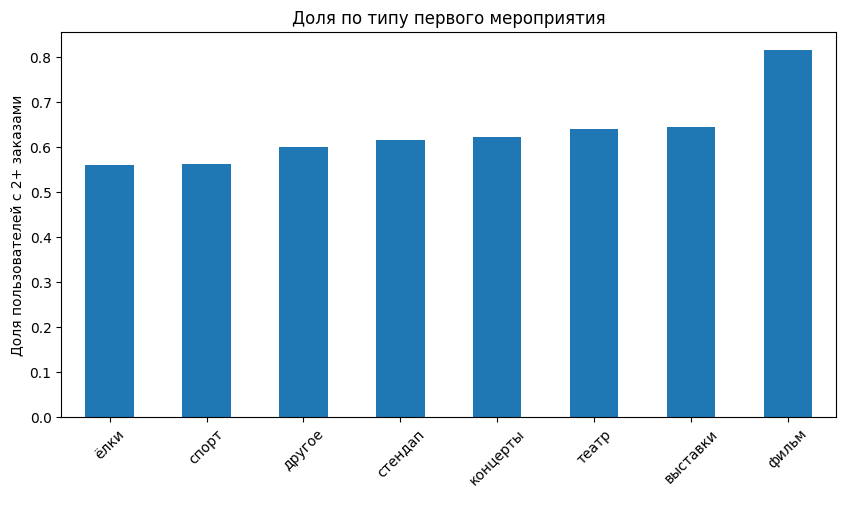

In [43]:
# Сегмент: тип первого мероприятия

event_return.sort_values('return_rate', ascending=True).plot(
    x='first_event_type',
    y='return_rate',
    kind='bar',
    figsize=(10,5),
    legend=False,
    title='Доля по типу первого мероприятия',
    ylabel='Доля пользователей с 2+ заказами',
    xlabel=' ',
    rot=45
)

plt.show()

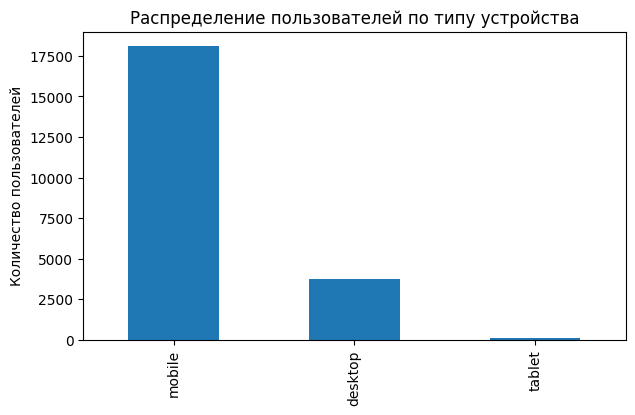

In [44]:
# распределение пользователей по типу устройства первой покупки

# группировка
device_segments = user_profile.groupby('first_device').agg(
    users=('user_id', 'count')
).reset_index()

# визуализация
device_segments.sort_values('users', ascending=False).plot(
    x='first_device',
    y='users',
    kind='bar',
    figsize=(7,4),
    legend=False,
    title='Распределение пользователей по типу устройства',
    ylabel='Количество пользователей',
    xlabel=''
)

plt.show()

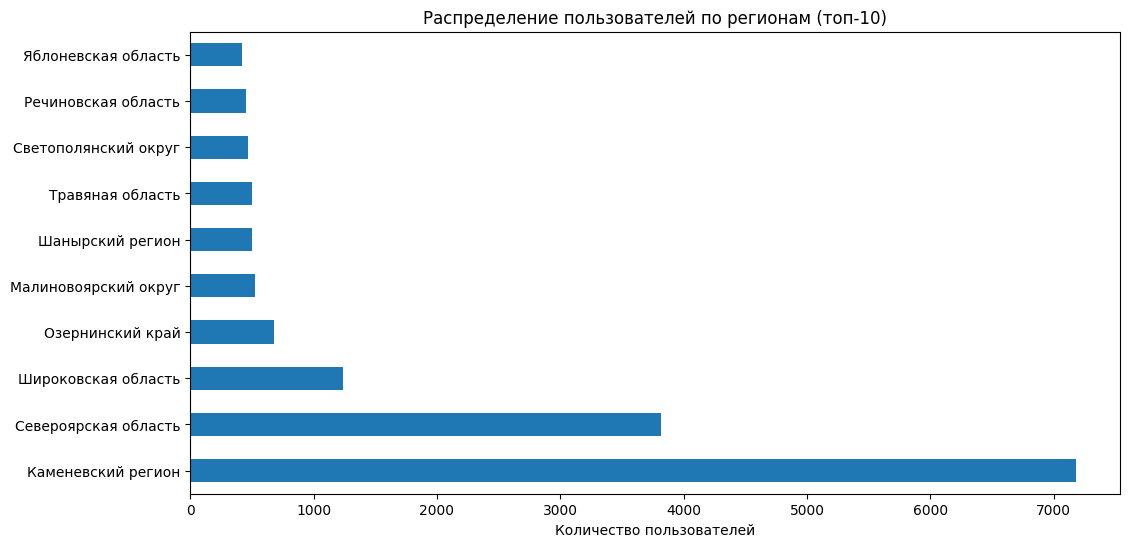

In [45]:
# распределение пользователей по региону первого заказа (топ-10)

# группировка
region_segments = user_profile.groupby('first_region').agg(
    users=('user_id', 'count')
).reset_index()

# визуализация
top_regions = region_segments.sort_values('users', ascending=False).head(10)
top_regions.plot(
    x='first_region',
    y='users',
    kind='barh',
    figsize=(12,6),
    legend=False,
    title='Распределение пользователей по регионам (топ-10)',
    ylabel='',
    xlabel='Количество пользователей'
)

plt.show()

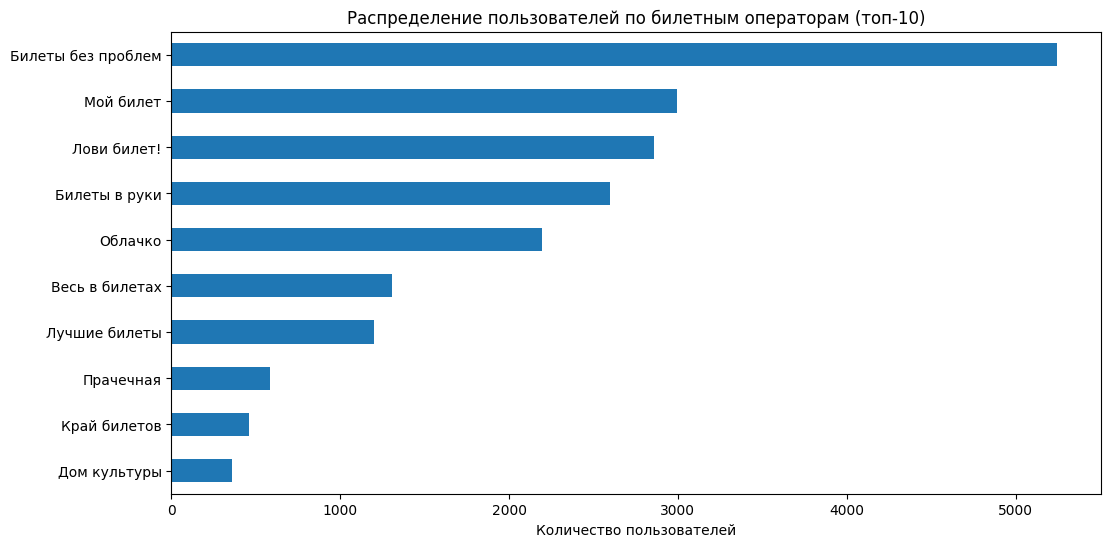

In [46]:
# распределение пользователей по билетным операторам первого заказа

service_segments = user_profile.groupby('first_service').agg(
    users=('user_id', 'count')
).reset_index()

top_services = service_segments.sort_values('users', ascending=False).head(10)

top_services.sort_values('users').plot(
    x='first_service',
    y='users',
    kind='barh',
    figsize=(12,6),
    legend=False,
    title='Распределение пользователей по билетным операторам (топ-10)',
    xlabel='Количество пользователей',
    ylabel=''
)

plt.show()

## Вывод

Пользователи чаще возвращаются после первого заказа в сегменте **фильмы** — процент повторных заказов составляет около 81%, что является максимальным значением среди типов мероприятий. Также стоит отметить, что процент возвратов в других категориях также не низок - около 55%-65%.

По типу устройства ситуация предсказуемая: из-за большой аудитории пользователей **мобильных устройств** процент возврата там больше ( >17.000 возвращается за повторным заказом), чем в других категориях.

В регионах лидируют **Каменевский регион** (>7.000 пользователей) и Североярская область (чуть меньше 4.000 пользователей).

Билетный оператор **Билеты без проблем** является лидером по числу пользователей ( >5.000).



Успешные "точки входа" присутствуют — это сегменты, где доля повторных заказов выше среднего уровня по выборке (около 62%). В первую очередь это пользователи, чей первый заказ связан с фильмами, выставками и театром.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [47]:
# проверяем первую гипотезу
event_return.loc[
    event_return['first_event_type'].isin(['спорт', 'концерты']),
    ['first_event_type', 'users', 'return_rate']
]

,first_event_type,users,return_rate
2,концерты,9656,0.622204
3,спорт,804,0.562189


In [48]:
# проверяем вторую гипотезу
region_return = user_profile.groupby('first_region').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

region_return.sort_values('users', ascending=False).head(10)

,first_region,users,return_rate
23,Каменевский регион,7179,0.629057
60,Североярская область,3814,0.641846
77,Широковская область,1238,0.650242
45,Озернинский край,680,0.551471
41,Малиновоярский округ,529,0.567108
76,Шанырский регион,503,0.673956
74,Травяная область,498,0.618474
57,Светополянский округ,466,0.663090
52,Речиновская область,449,0.630290
78,Яблоневская область,416,0.598558


## Выводы

### Гипотеза 1
Гипотеза **не подтвердилась**. Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются *реже*, чем пользователи, начавшие с концертов.

### Гипотеза 2
Гипотеза **подтвердилась частично**. В крупнейших регионах доля повторных заказов чаще находится на среднем уровне или выше среднего: *Каменевский регион — 62.9%*, *Североярская область — 64.3%*. Однако прямой устойчивой зависимости не наблюдается: *Озернинский край показывает лишь 54.9% возвратов*.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [49]:
one_order = user_profile[user_profile['is_two'] == 0]
repeat_users = user_profile[user_profile['is_two'] == 1]

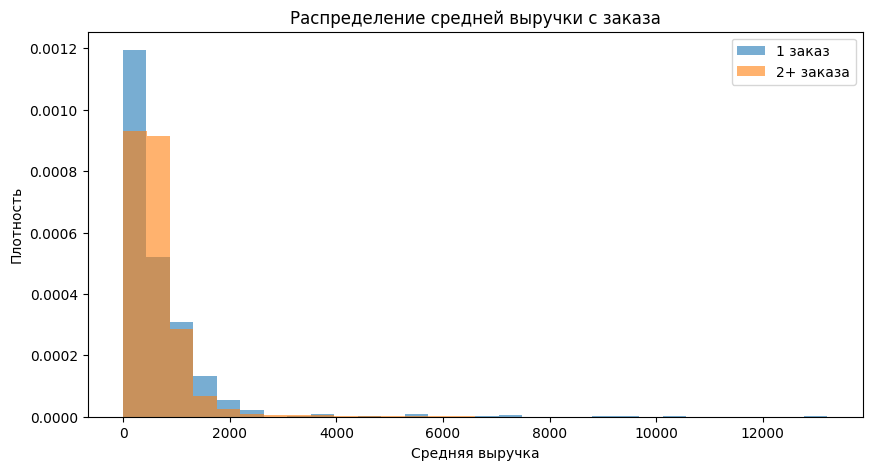

In [50]:
plt.figure(figsize=(10,5))

# пользователи с одним заказом
plt.hist(
    one_order['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='1 заказ'
)

# пользователи с 2+ заказами
plt.hist(
    repeat_users['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='2+ заказа'
)

plt.title('Распределение средней выручки с заказа')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность')
plt.legend()
plt.show()

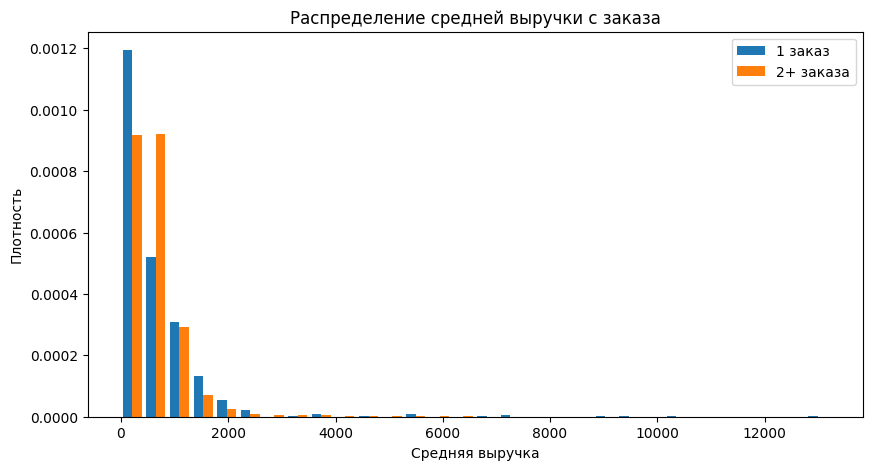

In [51]:
# для своего удобства сделал гистограмму, где одно не накладывается на другое
# для своего удобства сделал гистограмму, где одно не накладывается на другое

plt.figure(figsize=(10,5))

plt.hist(
    [one_order['avg_revenue_rub'], repeat_users['avg_revenue_rub']],
    bins=30,
    density=True,
    label=['1 заказ', '2+ заказа']
)

plt.title('Распределение средней выручки с заказа')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность')
plt.legend()
plt.show()

# для своего удобства сделал гистограмму, где одно не накладывается на другое
# для своего удобства сделал гистограмму, где одно не накладывается на другое


## Ответы на вопросы:

1. В обеих группах основная часть пользователей находится в диапазоне от **0 до 2000 руб.** 
    Пиковые значения у группы с 1 заказом находятся приходятся на самые низкие значения - **до 500 руб.**
    У группы с ≥2 заказами пиковые значения немного ниже, но при этом наблюдается два пика - один в диапазоне **"до 500 руб."** и второй около **1000 руб.**

2. Существенных различий между группами нет, хотя у пользователей с ≥2 заказами распределение немного смещено в сторону высоких показателей выручки. 

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [52]:
# пользователи с 2–4 заказами
users_2_4 = user_profile[(user_profile['orders_count'] >= 2) & (user_profile['orders_count'] <= 4)]

# пользователи с 5+ заказами
users_5_plus = user_profile[user_profile['orders_count'] >= 5]

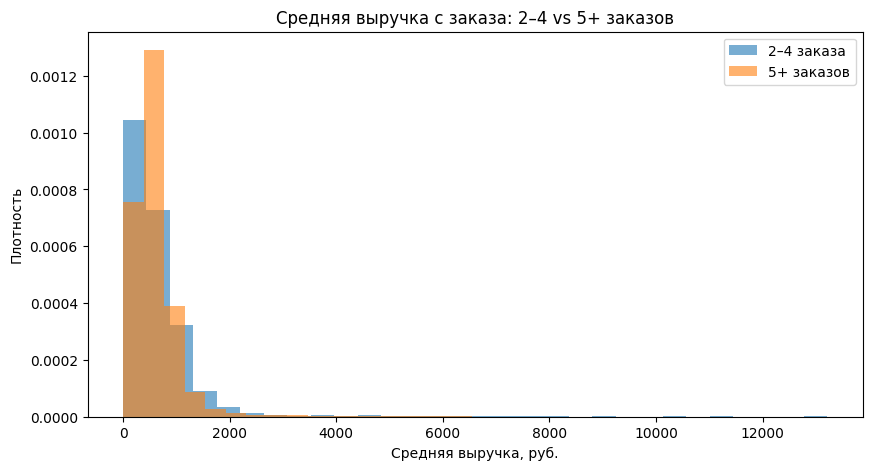

In [53]:
plt.figure(figsize=(10,5))

# группа 2–4 заказа
plt.hist(
    users_2_4['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='2–4 заказа'
)

# группа 5+ заказов
plt.hist(
    users_5_plus['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='5+ заказов'
)

plt.title('Средняя выручка с заказа: 2–4 vs 5+ заказов')
plt.xlabel('Средняя выручка, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

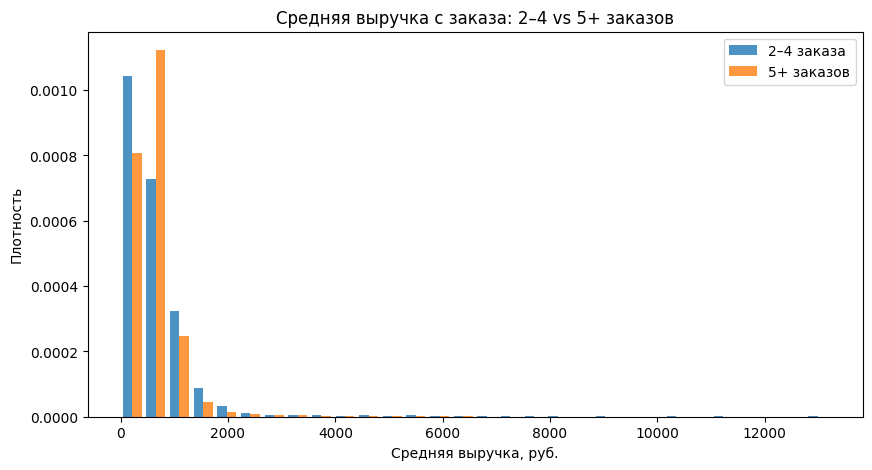

In [54]:
# для своего удобства сделал гистограмму, где одно не накладывается на другое
# для своего удобства сделал гистограмму, где одно не накладывается на другое

plt.figure(figsize=(10,5))

# две группы рядом
plt.hist(
    [users_2_4['avg_revenue_rub'], users_5_plus['avg_revenue_rub']],
    bins=30,
    alpha=0.8,
    density=True,
    label=['2–4 заказа', '5+ заказов']
)

plt.title('Средняя выручка с заказа: 2–4 vs 5+ заказов')
plt.xlabel('Средняя выручка, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

# для своего удобства сделал гистограмму, где одно не накладывается на другое
# для своего удобства сделал гистограмму, где одно не накладывается на другое


## Ответы на вопросы:

Существенных различий между группами не наблюдается, в обеих группах основная часть пользователей сосредоточена в диапазоне **от 0 до 2000 руб.** *(до 1500 руб.)*

При этом, у пользователей с **5+ заказами** распределение немного смещено вправо. Пиковые значения находятся около 1000 руб., в то время, как у пользователей с 2-4 заказами пик ближе к ~200 руб.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [55]:
# общая статистика
user_profile['avg_tickets'].describe()

count    21920.000000
mean         2.742845
std          0.912611
min          1.000000
25%          2.000000
50%          2.750000
75%          3.072321
max         11.000000
Name: avg_tickets, dtype: float64

In [56]:
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets'],
    bins=[1, 2, 3, 5, 100], # указываем 100, т.к. 12 - максимум
    labels=['1–2', '2–3', '3–5', '5+'],
    right=True,
    include_lowest=True
)

In [57]:
# анализируем сегменты

tickets_analysis = user_profile.groupby('tickets_segment').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

tickets_analysis

,tickets_segment,users,return_rate
0,1–2,6175,0.402105
1,2–3,10185,0.748257
2,3–5,5366,0.628215
3,5+,194,0.329897


## Ответы на вопросы:

1. Сегменты пользователей распределены неравномерно. Основовная часть пользователей сосредоточена в сегменте **"2-3 билета"** (10.185 пользователей). Почти 75% пользователей совершают повторную покупаку.

В то же время, в других сегментах пользователей ощутимо меньше: 5-6 тысяч пользователей в сегментах **1-2** и **3-5** покупок (с долей 40% и 62% соответственно) и 194 пользователя в сегменте **5+ покупок**.

2. Частично да. Самая высокая доля повторных покупок у сегмента **2–3 билета** — **~75%**. Самая низкая — у сегмента **5+ билетов** - 33%.
При этом, нельзя сказать, что эти показатели сильно аномальны. Но они, действительно, сильно отклоняются друг от друга.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [58]:
# переводим в datetime
user_profile['first_order_dt'] = pd.to_datetime(user_profile['first_order_dt'])

# создаём столбец с днём недели
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.day_name()

In [59]:
# группируем
weekday_analysis = user_profile.groupby('first_weekday').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

weekday_analysis # выводим результаты

,first_weekday,users,return_rate
0,Friday,3263,0.600061
1,Monday,2954,0.632363
2,Saturday,3469,0.643413
3,Sunday,2825,0.603540
4,Thursday,3124,0.595070
5,Tuesday,3200,0.621875
6,Wednesday,3085,0.624635


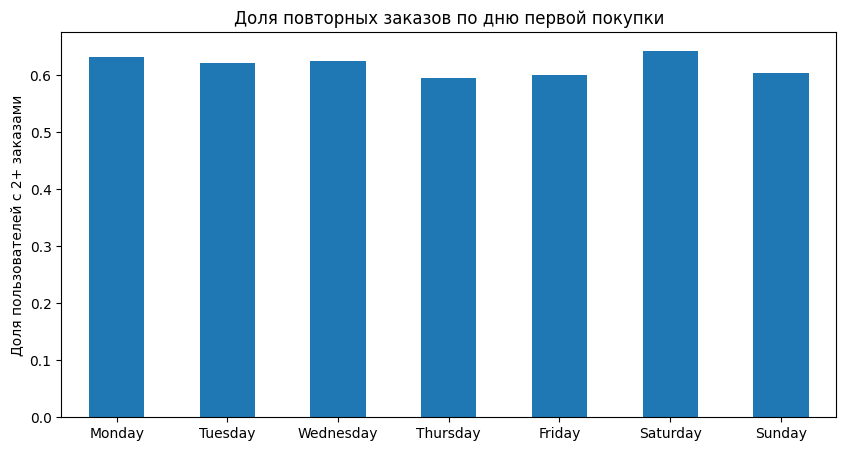

In [60]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# делаем категориальный тип, чтобы сортировка шла по порядку, а не по алфавиту
weekday_analysis['first_weekday'] = pd.Categorical(
    weekday_analysis['first_weekday'],
    categories=order,
    ordered=True
)


weekday_analysis = weekday_analysis.sort_values('first_weekday')

# график доли повторных заказов
weekday_analysis.plot(
    x='first_weekday',
    y='return_rate',
    kind='bar',
    figsize=(10,5),
    legend=False,
    title='Доля повторных заказов по дню первой покупки',
    ylabel='Доля пользователей с 2+ заказами',
    xlabel='',
    rot=0
)

plt.show()

## Ответ на вопрос:

День недели первой покупки практически не влияет на вероятность повторного заказа. Доли повторных заказов по всем дням находятся близко друг к другу (от 59% до 64%).

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [61]:
# делим пользователей на две группы:
# 2–4 заказа и 5+ заказов
interval_analysis = user_profile.groupby(
    pd.cut(
        user_profile['orders_count'],
        bins=[2, 4, 100],
        labels=['2–4 заказа', '5+ заказов'],
        include_lowest=True
    )
).agg(
    avg_interval=('avg_days_between', 'mean'), # средний интервал между заказами
    users=('user_id', 'count') # количество пользователей в группе
).reset_index()

# выводим результат
interval_analysis

,orders_count,avg_interval,users
0,2–4 заказа,21.117207,7181
1,5+ заказов,9.897232,6005


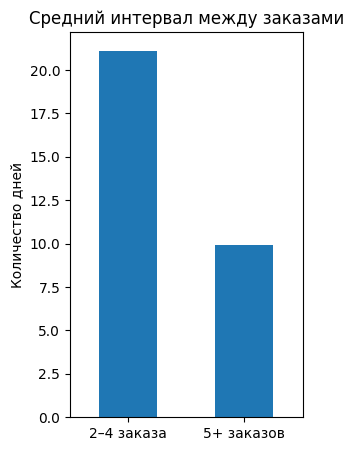

In [62]:
# визуализируем

interval_analysis.plot(
    x='orders_count',
    y='avg_interval',
    kind='bar',
    figsize=(3,5),
    legend=False,
    title='Средний интервал между заказами',
    ylabel='Количество дней',
    xlabel='',
    rot=0
)

plt.show()

## Ответ на вопрос:

Пользователи, совершившие **5 и более** заказов, покупают билеты заметно чаще: интервал между покупками, в среднем, составляет 9.9 дней. В то же время, у пользователей с **2-4 заказами** заказами интервал, в среднем, 21.1 день.

Можено предположить, что на эту статистику могли сильно повлиять пользователи, которые делают заказы слишком редко: из-за малой активности и интервалом 250 дней, к примеру, между покупками сильно влияет на данные.

У пользователей с *5 и более* заказами эта проблема может быть выражена заметно меньше, потому что пользователи стали лояльнее к сервису и с большей вероятностью вернутся именно к Яндекс.Афише

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [63]:
# статистика по числу заказов
user_profile['orders_count'].describe()

count    21920.000000
mean        13.193157
std        122.132781
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10243.000000
Name: orders_count, dtype: float64

In [64]:
# сегментируем пользователей по числу заказов
user_profile['orders_segment'] = pd.cut(
    user_profile['orders_count'],
    bins=[0, 1, 4, 11000],
    labels=['1 заказ', '2–4 заказа', '5+ заказов'],
    right=True
)

In [65]:
# указываем признаки для анализа
corr_data = user_profile[
    [
        'orders_segment',
        'first_device',
        'first_service',
        'first_region',
        'first_event_type',
        'avg_revenue_rub',
        'avg_tickets',
        'avg_days_between'
    ]
].copy()

In [66]:
# матрица корреляций

phik_matrix = corr_data.phik_matrix(

    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets',
        'avg_days_between'
    ]
)

phik_matrix

,orders_segment,first_device,first_service,first_region,first_event_type,avg_revenue_rub,avg_tickets,avg_days_between
orders_segment,1.000000,0.064975,0.086238,0.126195,0.052763,0.137695,0.390752,0.390834
first_device,0.064975,1.000000,0.106861,0.180442,0.075597,0.025126,0.046038,0.017840
first_service,0.086238,0.106861,1.000000,0.696606,0.574145,0.291592,0.066818,0.043299
first_region,0.126195,0.180442,0.696606,1.000000,0.504078,0.555058,0.166397,0.058578
first_event_type,0.052763,0.075597,0.574145,0.504078,1.000000,0.144135,0.094334,0.047378
avg_revenue_rub,0.137695,0.025126,0.291592,0.555058,0.144135,1.000000,0.294967,0.000000
avg_tickets,0.390752,0.046038,0.066818,0.166397,0.094334,0.294967,1.000000,0.101495
avg_days_between,0.390834,0.017840,0.043299,0.058578,0.047378,0.000000,0.101495,1.000000


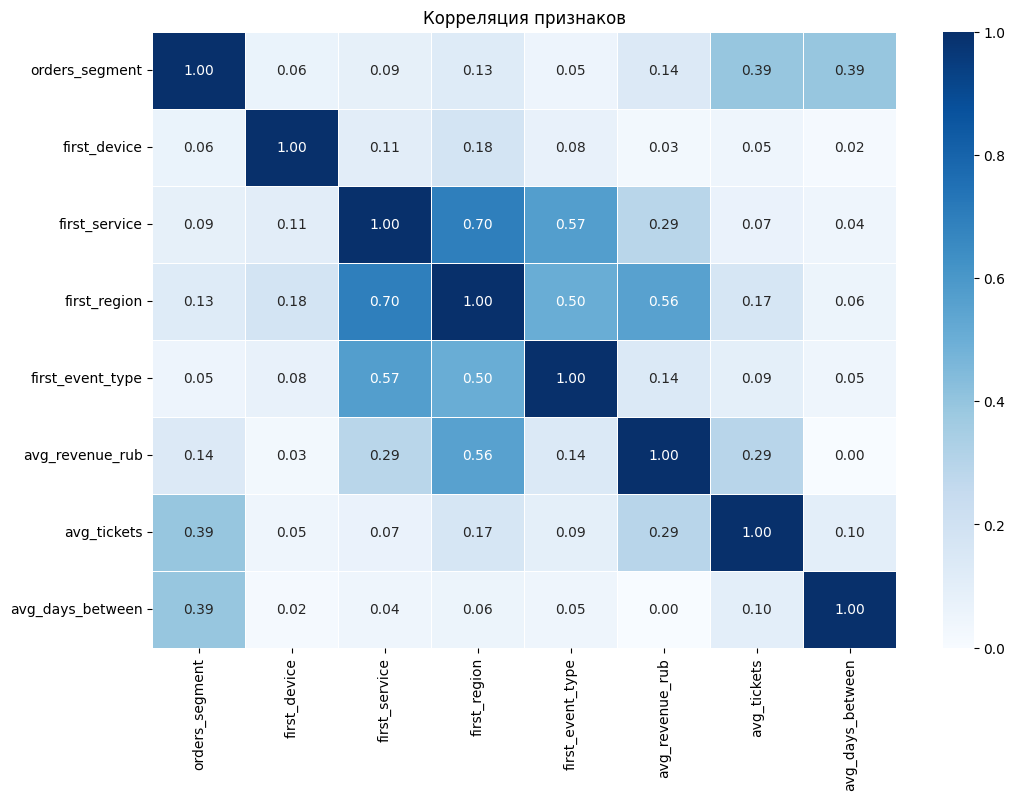

In [67]:
# строим тепловую карту корреляций

plt.figure(figsize=(12,8))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Корреляция признаков')
plt.show()

In [68]:
# отдельно указываем корреляцию orders_segment
phik_matrix['orders_segment'].sort_values(ascending=False)

orders_segment      1.000000
avg_days_between    0.390834
avg_tickets         0.390752
avg_revenue_rub     0.137695
first_region        0.126195
first_service       0.086238
first_device        0.064975
first_event_type    0.052763
Name: orders_segment, dtype: float64

## Ответ на вопрос:

Наиболее сильная связь с количеством заказов встречается у `avg_tickets` и `avg_days_between` - по **0.39** у каждого.

Ощутимо слабее связаны:
- `avg_revenue_rub` - **0.14**;
- `first_region` - **0.13**;
- `first_service` - **0.09**;
- `first_device` - **0.06**

Самая слабая связь выражена у `first_event_type` - **0.05**

### Общий вывод:
Больше всего на количество заказов влияют то, сколько билетов обычно покупает пользователь и как часто он делает покупки. Характеристики первого заказа влияют слабо.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

 ## В ходе этого проекта были подготовлены и обработаны данные о заказах пользователей сервиса Яндекс Афиша. 
 
 К изначальной таблице были присоединены несколько дополнительных, так как в первой не хватало данных для полного анализа.
- К изначальной таблице были присоединены Регион пользователя (`region_name`), город пользователя (`city_name`) и категория мероприятия (`event_type_main`).

- Также, потом был добавлен столбец с количеством дней между покупками пользователя (`days_since_prev`).

Для корректного сравнения выручки *заказы, оплаченные в тенге, были переведены в рубли по курсу валют на дату покупки* (`revenue_rub`). Это позволило анализировать все операции в единой валюте.

Также в данных были выявлены выбросы по количеству заказов и отдельным финансовым показателям. При анализе они учитывались отдельно, а в чувствительных задачах использовалась сегментация пользователей, чтобы экстремальные значения не влияли на результаты.

## Пользователи и структура заказов

- В выборке, что мы исследуем, содержится данные о **21.920 пользователях**.
- Бо́льшая часть пользователей совершает небольшое количество заказов:
  - 25% пользователей совершили только **1 заказ**;
  - Медианное значение составляет **2 заказа**;
  - 75% пользователей совершили **не более 5 заказов**
  
  Это говорит о том, что среди всей выборки преобладают пользователи с низкой и средне-низкой активностью.

### Дополнительные показатели

- В ходе анализа также были рассчитаны средняя выручка с заказа (`avg_revenue_rub`), среднее количество билетов в заказе (`avg_tickets`), доля пользователей с повторными заказами (`is_two`) и средний интервал между заказами (`avg_days_between`).

  Эти показатели помогли понять сколько дохода приносят пользователи, как часто они возвращаются и насколько активно пользуются сервисом.
  

## Признаки первого заказа и возврат пользователей

- **Тип первого мероприятия:** наиболее высокая доля повторных заказов наблюдалась у пользователей, чей первый заказ был связан с фильмами и выставками. Более низкие значения были у пользователей, начавших со спортивных мероприятий и ёлок.

- **Тип устройства:** большая часть пользователей совершила первую покупку с мобильного устройства. Но это можно связать с большей популярностью мобильных устройств в целом. При этом заметных различий в возврате между устройствами выявлено не было.

- **Регион и билетный оператор:** по объёму пользователей выделялись отдельные регионы и крупные билетные операторы, однако выраженного влияния этих признаков на возврат пользователей не было выявлено.

## Связь средней выручки и количества билетов с повторными покупками

- **Средняя выручка с заказа** (`avg_revenue_rub`): у пользователей с повторными покупками средняя выручка немного выше, чем у клиентов с одним заказом. Это говорит о том, что более дорогие заказы чаще связаны с возвратом пользователя.

- **Среднее количество билетов** (`avg_tickets`): наиболее высокая доля повторных заказов наблюдается у пользователей, которые в среднем покупают **2–3 билета** за заказ. При меньшем и большем количестве билетов вероятность возврата ниже.

    Таким образом, можно сказать, что пользователи с более крупным заказом и покупкой нескольких билетов чаще совершают повторные покупки.

## Влияние временных характеристик на удержание пользователей

- **День недели первой покупки:** заметного влияния дня недели на вероятность возврата пользователя не выявлено. Доля повторных заказов по дням недели различалась незначительно - около 60% для каждого из дней недели.

- **Интервал между покупками (`avg_days_between`):** пользователи с **5 и более заказами** совершают покупки заметно чаще. Средний интервал между заказами у них ниже, чем у пользователей с **2–4 заказами**.

  **Вывод**: главным временным фактором удержания является частота покупок. Чем меньше времени проходит между заказами, тем выше вероятность того, что пользователь останется активным клиентом сервиса.

## Какие признаки пользователя сильнее всего связаны с количеством заказов?

- **Наиболее сильная связь:** максимальные значения коэффициента `phi_k` наблюдаются у `avg_tickets` и `avg_days_between` — по **0.39**.

- **Умеренная связь:** у `avg_revenue_rub` коэффициент составил **0.14**, у `first_region` — **0.13**.

- **Слабая связь:** признаки первого заказа (`first_device`, `first_service`, `first_event_type`) показали низкую связь с количеством заказов - от 0.05 до 0.09.

  По результатам анализа делаем вывод, что число заказов в большей степени зависит от частоты покупок и среднего размера заказа, чем от характеристик первого заказа пользователя.

## Рекомендации по итогам исследования

- **Удерживать активных клиентов**: рекомендуется использовать бонусные программы и персональные рекомендации для пользователей с высокой частотой покупок, поскольку они формируют наиболее ценную часть аудитории.

- **Развивать групповые покупки:** продвигать сценарии семейного и совместного посещения мероприятий, поскольку пользователи с 2–3 билетами показывают наиболее высокий уровень возврата.

- **Работать с пользователями одного заказа:** выделить клиентов, совершивших только одну покупку, в отдельный сегмент для повторного вовлечения, так как именно здесь сосредоточен основной резерв роста повторных продаж.

    - **Стимулировать второй заказ**: Афише стоит запускать персональные предложения, напоминания и промокоды в первые недели после первой покупки, так как ранний возврат повышает вероятность дальнейшей активности пользователя.



- **Фокусироваться на поведении пользователей:** при прогнозировании повторных покупок больше внимания уделять частоте заказов, интервалам между покупками и размеру заказа, чем характеристикам первого заказа.

- **Использовать региональные различия:** адаптировать маркетинговые активности под крупные регионы и наиболее востребованные категории мероприятий, где сосредоточен основной поток пользователей.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**


https://github.com/dmmmmmd/afisha-analysis-32198428148#
